## Imports

In [22]:
!pip install -r requirements.txt -q
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu118
!pip install accelerate -U

Looking in indexes: https://download.pytorch.org/whl/cu118


In [23]:
%pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.


## Setup — Imports, Constants & Model Definitions

In [24]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from utils.MatrixVectorizer import MatrixVectorizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_DIR      = "data"
TRAIN_LR_PATH = os.path.join(DATA_DIR, "lr_train.csv")
TRAIN_HR_PATH = os.path.join(DATA_DIR, "hr_train.csv")

EPOCHS     = 200
LR         = 1e-3
BATCH_SIZE = 16
K_PROP     = 2
HIDDEN_DIM = 128
MLP_DIM    = 256

# Default training hyperparameters (overridden by Optuna best params after tuning)
DROPOUT           = 0.3
WEIGHT_DECAY      = 1e-3
PATIENCE          = 20
ALPHA             = 5.0
USE_WEIGHTED_LOSS = False
USE_LR_MAX_NORM   = False
LOWRANK_DIM       = 32
MODEL_TYPE        = "sgc"   # "sgc" | "lowrank"


In [25]:
%run utils/reproducibility.py

# Sync notebook constants with reproducibility.py
DEVICE = device
RANDOM_SEED = random_seed

CUDA is available. Using GPU.


In [26]:
def sanitize_vectors(x: np.ndarray) -> np.ndarray:
    # Ensure non-negative and finite values.
    x = np.nan_to_num(x)
    x[x < 0] = 0
    return x

def load_train_data(lr_path: str, hr_path: str):
    lr_vecs = pd.read_csv(lr_path).to_numpy(dtype=np.float32)
    hr_vecs = pd.read_csv(hr_path).to_numpy(dtype=np.float32)

    lr_vecs = sanitize_vectors(lr_vecs)
    hr_vecs = sanitize_vectors(hr_vecs)
    return lr_vecs, hr_vecs

def load_test_lr(path: str) -> np.ndarray | None:
    if not os.path.exists(path):
        print(f"[Phase 3] WARNING: test file not found: {path}. Skipping test inference.")
        return None
    vecs = pd.read_csv(path).to_numpy(dtype=np.float32)
    return sanitize_vectors(vecs)

def remove_outlier_subjects(lr_vecs: np.ndarray, hr_vecs: np.ndarray, n_std: float = 3.0):
    """Remove subjects whose mean HR edge weight is more than n_std std-devs above the mean."""
    per_subject_mean = hr_vecs.mean(axis=1)
    threshold = per_subject_mean.mean() + n_std * per_subject_mean.std()
    keep = per_subject_mean <= threshold
    n_removed = int((~keep).sum())
    if n_removed:
        print(f"[outlier filter] removed {n_removed} subject(s) with mean HR > {threshold:.3f}: "
              f"indices {np.where(~keep)[0].tolist()}")
    return lr_vecs[keep], hr_vecs[keep]


def vectors_to_matrices(vectors: np.ndarray, matrix_size: int) -> np.ndarray:
    mats = [MatrixVectorizer.anti_vectorize(v, matrix_size) for v in vectors]
    return np.stack(mats, axis=0)


def normalize_lr_mats(mats: np.ndarray) -> np.ndarray:
    """Per-subject max-normalization: scale each LR adjacency to [0, 1].

    The raw LR edge weights span [0, 12719], and test subjects have ~50% higher
    mean weight than train subjects.  Without this, the SGC propagation produces
    activations large enough to saturate the output sigmoid to 1.0 on test data.
    Dividing each subject by its own max decouples the model from absolute scale
    while preserving the relative connectivity pattern.
    """
    out = mats.copy()
    for i in range(len(out)):
        max_val = float(out[i].max())
        if max_val > 0.0:
            out[i] /= max_val
    return out


def normalize_adj_batch(adj: torch.Tensor) -> torch.Tensor:
    b, n, _ = adj.shape
    eye = torch.eye(n, device=adj.device).unsqueeze(0).expand(b, -1, -1)
    adj = adj + eye
    degree = adj.sum(dim=2)
    d_inv_sqrt = degree.pow(-0.5)
    d_inv_sqrt[d_inv_sqrt == float("inf")] = 0.0
    adj_norm = adj * d_inv_sqrt.unsqueeze(2) * d_inv_sqrt.unsqueeze(1)
    return adj_norm


In [27]:
# PHASE 1: improved SGC baseline
class SGCBaseline(nn.Module):
    """SGC (Simple Graph Convolution) baseline with Phase-1 improvements:
    - Linear output head (no sigmoid); predictions clipped to [0,1] at inference.
    - Dropout in MLP for regularisation.
    """
    def __init__(
        self,
        lr_nodes: int = 160,
        k_prop: int = 2,
        hidden_dim: int = 128,
        mlp_dim: int = 256,
        out_dim: int = 35778,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.lr_nodes = lr_nodes
        self.k_prop = k_prop
        self.node_proj = nn.Linear(lr_nodes, hidden_dim)
        self.mlp = nn.Sequential(
            nn.Linear(lr_nodes * hidden_dim, mlp_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, out_dim),
        )

    def forward(self, adj_lr: torch.Tensor) -> torch.Tensor:
        adj_norm = normalize_adj_batch(adj_lr)
        # SGC propagation: X' = (A_norm)^K X
        x = adj_lr
        for _ in range(self.k_prop):
            x = torch.bmm(adj_norm, x)
        h = self.node_proj(x)
        h_flat = h.reshape(h.size(0), -1)
        return self.mlp(h_flat)


## Model Definitions

Two candidate architectures explored during tuning:

- **`SGCBaseline`** — SGC propagation (K steps) → flatten → MLP → HR edge vector.
- **`LowRankHRGenerator`** — SGC encoder → low-rank node embeddings Z → A_hat = Z Zᵀ → vectorize.

`build_model_from_params(params)` is used by the Optuna objective to instantiate the selected architecture for each trial.


In [28]:
# PHASE 2: Low-rank HR generator
class LowRankHRGenerator(nn.Module):
    """Predicts HR adjacency as A_hat = Z @ Z^T (linear), vectorized to length 35778.

    Architecture:
      1. LR encoder: SGC propagation (K steps) → mean-pool over nodes → vector g.
      2. Decoder: g → Z of shape (B, 268, d)  via MLP + reshape.
      3. A_hat = Z @ Z^T; symmetrised + zero-diagonal; predictions clipped at inference.
      4. Differentiable upper-triangle extraction matching MatrixVectorizer column-first order.

    forward() returns shape (B, 35778) — same contract as SGCBaseline.
    """
    HR_NODES   = 268
    HR_VEC_DIM = 35778

    def __init__(
        self,
        lr_nodes:   int   = 160,
        k_prop:     int   = 2,
        hidden_dim: int   = 128,
        d:          int   = 32,
        dropout:    float = 0.3,
    ):
        super().__init__()
        self.lr_nodes = lr_nodes
        self.k_prop   = k_prop
        self.d        = d

        # Node-level projection (shared across LR positions)
        self.node_proj = nn.Linear(lr_nodes, hidden_dim)

        # MLP: global summary  →  268 * d
        self.decoder = nn.Sequential(
            nn.Linear(lr_nodes * hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, self.HR_NODES * d),
        )

        # Precompute upper-triangle index tensors in MatrixVectorizer
        #    column-first order so extraction is differentiable and consistent 
        rows, cols = [], []
        for col in range(self.HR_NODES):
            for row in range(col):   # row < col
                rows.append(row)
                cols.append(col)
        # Registered as buffers so they move to the right device automatically
        self.register_buffer("triu_row", torch.tensor(rows, dtype=torch.long))
        self.register_buffer("triu_col", torch.tensor(cols, dtype=torch.long))
        assert len(rows) == self.HR_VEC_DIM, "Index pre-computation mismatch."

    def forward(self, adj_lr: torch.Tensor) -> torch.Tensor:
        # 1. SGC propagation over LR graph
        adj_norm = normalize_adj_batch(adj_lr)
        x = adj_lr                                   # (B, 160, 160)
        for _ in range(self.k_prop):
            x = torch.bmm(adj_norm, x)

        h = self.node_proj(x)                        # (B, 160, hidden_dim)
        g = h.reshape(h.size(0), -1)                 # (B, 160*hidden_dim)

        # 2. Decode to HR node embeddings
        Z = self.decoder(g).view(-1, self.HR_NODES, self.d)  # (B, 268, d)

        # 3. Low-rank adjacency (linear — no sigmoid; clipped at inference)
        A_hat = torch.bmm(Z, Z.transpose(1, 2))              # (B, 268, 268)

        # Enforce symmetry + zero diagonal (all differentiable)
        A_hat = (A_hat + A_hat.transpose(1, 2)) * 0.5
        diag  = torch.eye(self.HR_NODES, device=A_hat.device, dtype=torch.bool)
        A_hat = A_hat.masked_fill(diag.unsqueeze(0), 0.0)

        # 4. Differentiable upper-triangle extraction
        #    Indexes matching MatrixVectorizer.vectorize column-first order  
        vec = A_hat[:, self.triu_row, self.triu_col]   # (B, 35778)
        return vec


def build_model(model_type: str = "sgc") -> nn.Module:
    """Factory: instantiates the chosen model with the current global hyper-params."""
    if model_type == "sgc":
        return SGCBaseline(
            lr_nodes=160, k_prop=K_PROP, hidden_dim=HIDDEN_DIM,
            mlp_dim=MLP_DIM, out_dim=35778, dropout=DROPOUT,
        )
    elif model_type == "lowrank":
        return LowRankHRGenerator(
            lr_nodes=160, k_prop=K_PROP, hidden_dim=HIDDEN_DIM,
            d=LOWRANK_DIM, dropout=DROPOUT,
        )
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {model_type!r}. Use 'sgc' or 'lowrank'.")


In [29]:
import copy

# Loss functions

class WeightedMAELoss(nn.Module):
    """Element-wise MAE weighted by w = 1 + alpha * y_true."""
    def __init__(self, alpha: float = 5.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        weights = 1.0 + self.alpha * target.detach()
        return (weights * (pred - target).abs()).mean()


def get_loss_fn(use_weighted: bool = False, alpha: float = 5.0) -> nn.Module:
    if use_weighted:
        return WeightedMAELoss(alpha=alpha)
    return nn.L1Loss()


# Training helpers

def train_epoch(model, loader, optimiser, loss_fn):
    model.train()
    running = 0.0
    for adj_lr, hr_vec in loader:
        adj_lr = adj_lr.to(DEVICE)
        hr_vec = hr_vec.to(DEVICE)
        optimiser.zero_grad()
        pred = model(adj_lr)
        loss = loss_fn(pred, hr_vec)
        loss.backward()
        optimiser.step()
        running += loss.item() * adj_lr.size(0)
    return running / len(loader.dataset)

def val_epoch_clipped_mae(model, loader) -> float:
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for adj_lr, hr_vec in loader:
            adj_lr = adj_lr.to(DEVICE)
            pred = model(adj_lr).cpu().numpy()
            preds.append(pred)
            gts.append(hr_vec.numpy())
    preds = postprocess(np.concatenate(preds, 0))
    gts   = np.concatenate(gts, 0)
    return float(np.mean(np.abs(preds - gts)))


def predict(model, loader) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            adj_lr = (batch[0] if isinstance(batch, (list, tuple)) else batch).to(DEVICE)
            pred   = model(adj_lr).cpu().numpy()
            preds.append(pred)
    return np.concatenate(preds, axis=0)


def postprocess(pred_vecs: np.ndarray) -> np.ndarray:
    pred_vecs = np.nan_to_num(pred_vecs)
    return np.clip(pred_vecs, 0.0, 1.0)


In [30]:
# Load and preprocess training data for the tuning objective
lr_vecs_raw, hr_vecs_raw = load_train_data(TRAIN_LR_PATH, TRAIN_HR_PATH)

assert lr_vecs_raw.shape == (167, 12720), f"Unexpected LR train shape: {lr_vecs_raw.shape}"
assert hr_vecs_raw.shape == (167, 35778), f"Unexpected HR train shape: {hr_vecs_raw.shape}"
print(f"[sanity] LR train : shape={lr_vecs_raw.shape}  range=[{lr_vecs_raw.min():.4f}, {lr_vecs_raw.max():.4f}]")
print(f"[sanity] HR train : shape={hr_vecs_raw.shape}  range=[{hr_vecs_raw.min():.4f}, {hr_vecs_raw.max():.4f}]")

lr_vecs, hr_vecs = remove_outlier_subjects(lr_vecs_raw, hr_vecs_raw)

lr_mats = vectors_to_matrices(lr_vecs, 160).astype(np.float32)
if USE_LR_MAX_NORM:
    lr_mats = normalize_lr_mats(lr_mats)
hr_vecs = hr_vecs.astype(np.float32)

print(f"LR matrices: {lr_mats.shape}  |  HR vectors: {hr_vecs.shape}")


[sanity] LR train : shape=(167, 12720)  range=[0.0000, 0.9990]
[sanity] HR train : shape=(167, 35778)  range=[0.0000, 0.9999]
[outlier filter] removed 2 subject(s) with mean HR > 0.434: indices [35, 71]
LR matrices: (165, 160, 160)  |  HR vectors: (165, 35778)


## PHASE 4 — Hyperparameter Tuning (Optuna)

Searches the following space using **TPE sampler** (Tree-structured Parzen Estimator):

| Parameter | Range |
|-----------|-------|
| `model_type` | `sgc`, `lowrank` |
| `k_prop` | 1 – 3 |
| `hidden_dim` | 64, 128, 256 |
| `mlp_dim` | 128, 256, 512 |
| `dropout` | 0.1 – 0.5 |
| `lowrank_dim` | 16, 32, 64 (lowrank only) |
| `use_weighted_loss` | True / False |
| `alpha` | 1.0 – 10.0 (weighted loss only) |
| `weight_decay` | 1e-4 – 1e-2 (log scale) |
| `patience` | 10, 20, 30 |

**Objective**: minimise OOF Flatten MAE over 3-fold CV.
Best parameters are printed and applied to subsequent cells.

In [31]:
%pip install optuna -q

Note: you may need to restart the kernel to use updated packages.


In [32]:
import optuna
import copy
from sklearn.metrics import mean_absolute_error as sk_mae

# ── Tuning settings ──────────────────────────────────────────────────────────
N_TRIALS   = 30    # total Optuna trials (increase for better coverage)
CV_SPLITS  = 3     # number of folds per trial (keep 3 to match main CV)
TUNE_EPOCHS = 200  # max epochs per fold during search (early-stopping applies)
# ─────────────────────────────────────────────────────────────────────────────

optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-epoch noise


def build_model_from_params(params: dict) -> nn.Module:
    """Construct a model from an Optuna trial parameter dict."""
    if params["model_type"] == "sgc":
        return SGCBaseline(
            lr_nodes=160,
            k_prop=params["k_prop"],
            hidden_dim=params["hidden_dim"],
            mlp_dim=params["mlp_dim"],
            out_dim=35778,
            dropout=params["dropout"],
        )
    else:  # lowrank
        return LowRankHRGenerator(
            lr_nodes=160,
            k_prop=params["k_prop"],
            hidden_dim=params["hidden_dim"],
            d=params["lowrank_dim"],
            dropout=params["dropout"],
        )


def objective(trial: optuna.Trial) -> float:
    """3-fold CV OOF Flatten MAE — Optuna minimises this."""

    # ── Sample hyperparameters ───────────────────────────────────────────────
    model_type        = trial.suggest_categorical("model_type", ["sgc", "lowrank"])
    use_weighted_loss = trial.suggest_categorical("use_weighted_loss", [False, True])

    # Conditional parameters: only relevant to one branch
    lowrank_dim = (
        trial.suggest_categorical("lowrank_dim", [16, 32, 64])
        if model_type == "lowrank"
        else 32
    )
    alpha = (
        trial.suggest_float("alpha", 1.0, 10.0)
        if use_weighted_loss
        else 5.0
    )

    params = {
        "model_type":        model_type,
        "k_prop":            trial.suggest_int("k_prop", 1, 3),
        "hidden_dim":        trial.suggest_categorical("hidden_dim", [64, 128, 256]),
        "mlp_dim":           trial.suggest_categorical("mlp_dim", [128, 256, 512]),
        "dropout":           trial.suggest_float("dropout", 0.1, 0.5),
        "lowrank_dim":       lowrank_dim,
        "use_weighted_loss": use_weighted_loss,
        "alpha":             alpha,
        "weight_decay":      trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True),
        "patience":          trial.suggest_categorical("patience", [10, 20, 30]),
    }

    loss_fn   = get_loss_fn(params["use_weighted_loss"], params["alpha"])
    kf        = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_SEED)

    oof_preds_t, oof_gts_t = [], []

    for train_idx, val_idx in kf.split(lr_mats):
        train_loader = DataLoader(
            TensorDataset(
                torch.from_numpy(lr_mats[train_idx]),
                torch.from_numpy(hr_vecs[train_idx]),
            ),
            batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
        )
        val_loader = DataLoader(
            TensorDataset(
                torch.from_numpy(lr_mats[val_idx]),
                torch.from_numpy(hr_vecs[val_idx]),
            ),
            batch_size=BATCH_SIZE, shuffle=False,
        )

        model     = build_model_from_params(params).to(DEVICE)
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR, weight_decay=params["weight_decay"]
        )

        best_val_mae   = float("inf")
        best_weights   = None
        patience_count = 0

        for epoch in range(1, TUNE_EPOCHS + 1):
            train_epoch(model, train_loader, optimizer, loss_fn)
            # Use clipped MAE for early stopping — consistent with the objective metric
            v_mae = val_epoch_clipped_mae(model, val_loader)

            if v_mae < best_val_mae - 1e-7:
                best_val_mae   = v_mae
                best_weights   = copy.deepcopy(model.state_dict())
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= params["patience"]:
                    break

        model.load_state_dict(best_weights)
        fold_preds = postprocess(predict(model, val_loader))
        oof_preds_t.append(fold_preds)
        oof_gts_t.append(hr_vecs[val_idx])

    oof_preds_all = np.concatenate(oof_preds_t, axis=0)
    oof_gts_all   = np.concatenate(oof_gts_t,   axis=0)
    return float(sk_mae(oof_gts_all.flatten(), oof_preds_all.flatten()))


# ── Run study ────────────────────────────────────────────────────────────────
print(f"Starting Optuna search: {N_TRIALS} trials × {CV_SPLITS}-fold CV each")
print(f"Early-stopping patience is sampled per trial (10/20/30).\n")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="brain_sr_tuning",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n{'='*55}")
print(f"  Best OOF Flatten MAE : {study.best_value:.6f}")
print(f"  Best trial number    : {study.best_trial.number}")
print(f"{'='*55}")
print("  Best parameters:")
for k, v in study.best_params.items():
    print(f"    {k:<22s} = {v}")


Starting Optuna search: 30 trials × 3-fold CV each
Early-stopping patience is sampled per trial (10/20/30).



  0%|          | 0/30 [00:00<?, ?it/s]


  Best OOF Flatten MAE : 0.128385
  Best trial number    : 28
  Best parameters:
    model_type             = sgc
    use_weighted_loss      = False
    k_prop                 = 2
    hidden_dim             = 64
    mlp_dim                = 512
    dropout                = 0.2846780493863432
    weight_decay           = 0.007023868736399456
    patience               = 20


Top-30 trials by OOF Flatten MAE:


,number,value,alpha,dropout,hidden_dim,k_prop,lowrank_dim,mlp_dim,model_type,patience,use_weighted_loss,weight_decay,state
0,28,0.128385,NaN,0.284678,64,2,NaN,512,sgc,20,False,0.007024,COMPLETE
1,19,0.128423,NaN,0.100834,64,1,NaN,512,sgc,20,False,0.006017,COMPLETE
2,20,0.128866,NaN,0.289227,64,2,NaN,512,sgc,10,False,0.000521,COMPLETE
3,27,0.129105,NaN,0.217045,64,2,NaN,512,sgc,20,False,0.001691,COMPLETE
4,13,0.129180,NaN,0.105287,64,1,NaN,512,sgc,20,False,0.000785,COMPLETE
5,3,0.129414,NaN,0.156370,256,1,NaN,512,sgc,20,False,0.004022,COMPLETE
6,15,0.129439,NaN,0.151130,64,1,NaN,512,sgc,20,False,0.001776,COMPLETE
7,23,0.129577,NaN,0.315918,64,1,NaN,512,sgc,10,False,0.000930,COMPLETE
8,12,0.129744,NaN,0.250998,64,1,NaN,512,sgc,30,False,0.000113,COMPLETE
9,22,0.129909,NaN,0.106267,64,2,NaN,512,sgc,10,False,0.000287,COMPLETE


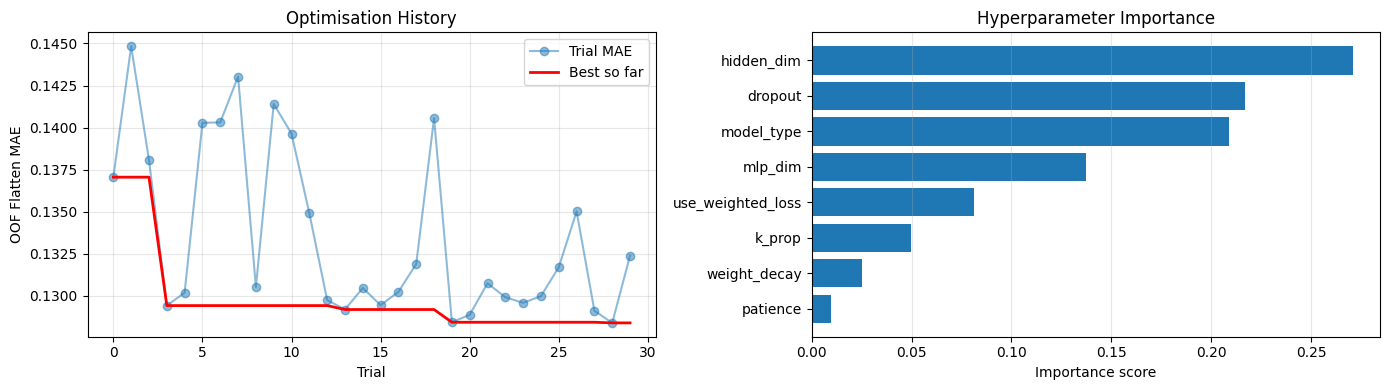


Applying best parameters to notebook globals ...
  MODEL_TYPE=sgc, K_PROP=2, HIDDEN_DIM=64, MLP_DIM=512, DROPOUT=0.285
  LOWRANK_DIM=32, USE_WEIGHTED_LOSS=False, ALPHA=5.00, WEIGHT_DECAY=7.02e-03, PATIENCE=20


In [36]:
# ── Trial history table ───────────────────────────────────────────────────────
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
trials_df = trials_df.sort_values("value").reset_index(drop=True)
trials_df.columns = trials_df.columns.str.replace("params_", "", regex=False)
print("Top-30 trials by OOF Flatten MAE:")
display(trials_df.head(30))

# ── Optimisation history plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

values = [t.value for t in study.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
axes[0].plot(values,      "o-", alpha=0.5, label="Trial MAE")
axes[0].plot(best_so_far, "r-", lw=2,     label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("OOF Flatten MAE")
axes[0].set_title("Optimisation History")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

try:
    importances = optuna.importance.get_param_importances(study)
    names  = list(importances.keys())
    scores = list(importances.values())
    axes[1].barh(names[::-1], scores[::-1])
    axes[1].set_xlabel("Importance score")
    axes[1].set_title("Hyperparameter Importance")
    axes[1].grid(True, alpha=0.3, axis="x")
except Exception as e:
    axes[1].text(0.5, 0.5, f"Importance unavailable:\n{e}",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
os.makedirs("figs", exist_ok=True)
plt.savefig("figs/optuna_tuning_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Apply best parameters to notebook globals ─────────────────────────────────
best = study.best_params
print("\nApplying best parameters to notebook globals ...")
MODEL_TYPE        = best["model_type"]
K_PROP            = best["k_prop"]
HIDDEN_DIM        = best["hidden_dim"]
MLP_DIM           = best["mlp_dim"]
DROPOUT           = best["dropout"]
LOWRANK_DIM       = best["lowrank_dim"] if MODEL_TYPE == "lowrank" else 32
USE_WEIGHTED_LOSS = best["use_weighted_loss"]
ALPHA             = best["alpha"] if USE_WEIGHTED_LOSS else 5.0
WEIGHT_DECAY      = best["weight_decay"]
PATIENCE          = best["patience"]

print(f"  MODEL_TYPE={MODEL_TYPE}, K_PROP={K_PROP}, HIDDEN_DIM={HIDDEN_DIM}, "
      f"MLP_DIM={MLP_DIM}, DROPOUT={DROPOUT:.3f}")
print(f"  LOWRANK_DIM={LOWRANK_DIM}, USE_WEIGHTED_LOSS={USE_WEIGHTED_LOSS}, "
      f"ALPHA={ALPHA:.2f}, WEIGHT_DECAY={WEIGHT_DECAY:.2e}, PATIENCE={PATIENCE}")
